# Tiara — 平台 A 量測分析

**RTX 3090 (sm_86) · vLLM 0.28.0+cu129 · 2026-08-30/31**

這份 notebook 從 `results/` 讀**實測資料**產生所有圖表與數字。
所有繪圖與衍生計算都在 `analysis.py`，notebook 只負責呈現——
這樣論文的圖與這裡的圖必然一致，不會漂移。

## 三條規則（來自 `EXPERIMENT_PLAN.md` §0）

1. **沒量到就寫 `NOT_MEASURED`**，不估、不推。`analysis.py` 讀不到檔就 raise。
2. **每個數字可追溯到一條指令與一個輸出檔**。
3. **被 GPU 插隊污染的列不入分析**（`contaminated == True` 直接跳過）。

In [1]:
import sys; sys.path.insert(0, '.')
from analysis import *
import pandas as pd

D = load_all()
plt = style()
print('讀到：', {k: (len(v) if isinstance(v, list) else '…') for k, v in D.items()})

讀到： {'cost': '…', 'capacity': 10, 'idle': '…', 'recompute': 5, 'm3': 80, 'oracle': 10, 'traces': 2}


---
## 1. 成本模型：兩種成本，不是一種

「平時成本」是這個狀態閒著時佔多少 GPU 記憶體；
「取回成本」是被需要時要花多久。**壓成一個數字會得到「重算最貴所以永不重算」的錯誤結論。**

In [2]:
cost = D['cost']
print('取回成本（ms / block，block = 16 tokens）\n')
for k in ('gpu', 'cpu', 'ssd', 'recompute_base'):
    src = cost['_derivation'].get(k, '定義基準')
    print(f'  {k:16s} {cost[k]:8.4f}   ← {src}')
print(f"\n  重算的位置項    {cost['recompute_slope_per_token']:.5f} ms / block / 前序token")

取回成本（ms / block，block = 16 tokens）

  gpu                0.0000   ← 定義基準
  cpu                0.5884   ← (736.894 - 134.415) / 1024 blocks
  ssd                5.5360   ← (5803.3150000000005 - 134.415) / 1024 blocks
  recompute_base     4.0079   ← 513.011 / 128 blocks

  重算的位置項    0.00021 ms / block / 前序token


In [3]:
print('平時成本（KiB / token，已除以 GiB 正規化）\n')
rows = [{'dtype': k, 'KiB/token': v['kib_per_token'], '理想值': v['ideal_kib'],
         '額外': v['overhead_kib'], '相對 BF16': f"{v['rel_bf16']:.2f}×",
         '全距%': v['spread_pct']} for k, v in D['idle'].items()]
df_idle = pd.DataFrame(rows)
display(df_idle)
print('\n那多出來的 2 KiB 是 per-token-head 量化的 scale：')
print('  2 (K,V) × 32 層 × 8 KV head = 512 個 FP32 = 2,048 bytes = 2 KiB ✓')

平時成本（KiB / token，已除以 GiB 正規化）



,dtype,KiB/token,理想值,額外,相對 BF16,全距%
0,bf16,128.11,128.0,0.11,1.00×,0.00
1,fp8,64.04,64.0,0.04,2.00×,0.00
2,int8,66.04,64.0,2.04,1.94×,0.04
3,int4,34.02,32.0,2.02,3.77×,0.02



那多出來的 2 KiB 是 per-token-head 量化的 scale：
  2 (K,V) × 32 層 × 8 KV head = 512 個 FP32 = 2,048 bytes = 2 KiB ✓


### 為什麼一定要正規化

原始 token 數 run-to-run 會跳 **13.5%**，因為 KV pool 本身在 5.09 / 5.88 GiB
兩個值之間擺動。**除以 GiB 之後全距降到 0.04%**——證明抖動來自 pool 大小而非 dtype。

---
## 2. 重算成本隨位置**線性**成長（不是二次）

計畫書原文寫「attention 二次項」。整段 prefill 確為 $O(L^2)$，
但**固定大小的 block** 在位置 $P$ 重算是 $O(C \cdot P)$——對 $P$ 線性。

In [4]:
fit = fit_recompute_linear(D['recompute'])
print(f"C_recompute(P) = {fit['intercept_ms']:.1f} ms + "
      f"{fit['slope_ms_per_token']*1000:.2f} ms × (P/1000)")
print(f"線性擬合最大偏差 {100*fit['max_rel_error']:.1f}%（{fit['n_points']} 個點）")
print('→ 找不到二次成分。論文若寫「二次成長」，審稿人做這個實驗就會抓到。\n')
display(pd.DataFrame(D['recompute']))

C_recompute(P) = 508.1 ms + 26.81 ms × (P/1000)
線性擬合最大偏差 1.0%（5 個點）
→ 找不到二次成分。論文若寫「二次成長」，審稿人做這個實驗就會抓到。



,P,chunk,ms
0,0,2048,513.0
1,4096,2048,616.7
2,8192,2048,726.2
3,16384,2048,938.7
4,24576,2048,1173.5


---
## 3. SSD 與重算的優劣**隨位置反轉**

SSD 的取回成本是常數，重算隨位置成長。兩條線必然相交。
**我先前在 ctx=16,384 量測，平均位置恰好落在交叉點附近，因而得出「SSD 被支配」的錯誤結論。**

In [5]:
x0 = ssd_drop_crossover(D['cost'])
print(f'交叉點：位置 {x0:,.0f} token\n')
rows = []
for ctx in (8192, 16384, 32768, 131072, 524288):
    ap = ctx / 2
    d = drop_cost(D['cost'], ap)
    rows.append({'context': f'{ctx:,}', '平均位置': f'{ap:,.0f}',
                 '平均重算 (ms)': round(d, 2), 'SSD (ms)': round(D['cost']['ssd'], 2),
                 '誰便宜': '重算' if d < D['cost']['ssd'] else 'SSD',
                 '適合重算的比例': f'{min(100, 100*x0/ctx):.1f}%'})
display(pd.DataFrame(rows))
print('\n★ 量分層成本必須掃 context 長度。單點取值會得到相反的答案。')

交叉點：位置 7,278 token



,context,平均位置,平均重算 (ms),SSD (ms),誰便宜,適合重算的比例
0,"8,192","4,096",4.87,5.54,重算,88.8%
1,"16,384","8,192",5.73,5.54,SSD,44.4%
2,"32,768","16,384",7.45,5.54,SSD,22.2%
3,"131,072","65,536",17.77,5.54,SSD,5.6%
4,"524,288","262,144",59.05,5.54,SSD,1.4%



★ 量分層成本必須掃 context 長度。單點取值會得到相反的答案。


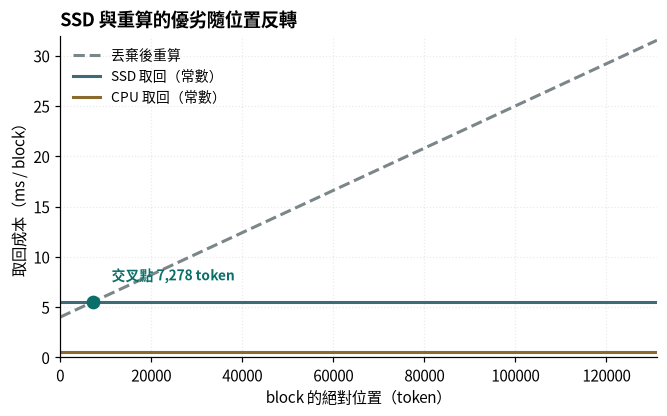

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.8))
fig_crossover(D, ax=ax); plt.show()

---
## 4. 容量：瓶頸已從記憶體轉為模型架構

BF16 權重佔 24 GB 裡的 15 GB，只剩 5.9 GiB 給 KV → 容量 41,648。
**AWQ-INT4 權重只要 4.7 GB → 剩 15 GiB → 容量 120K–548K。**

計畫書 §2 寫的主力設定本來就是 AWQ；先前一路跑 BF16，
導致整個實驗被鎖在短 context，進不了論文關心的 128K 區間。

In [7]:
df_cap = pd.DataFrame(D['capacity']).sort_values('kv_tokens')
caps = {'llama': 131072, 'qwen': 262144, 'mla': 163840}
df_cap['模型定址上限'] = [next((v for k, v in caps.items() if k in c), None)
                        for c in df_cap['config']]
df_cap['瓶頸'] = ['模型架構' if (l and t > l) else '記憶體'
                 for t, l in zip(df_cap['kv_tokens'], df_cap['模型定址上限'])]
display(df_cap[['config', 'weight', 'kv_dtype', 'kv_tokens', '模型定址上限', '瓶頸']])
n = (df_cap['瓶頸'] == '模型架構').sum()
print(f'\n{n}/{len(df_cap)} 個設定的 KV 容量已超出模型可定址長度。')
print('→ 單卡 3090 的 KV 記憶體不是長 context 的瓶頸。')

,config,weight,kv_dtype,kv_tokens,模型定址上限,瓶頸
0,llama-bf16,BF16,auto,41648,131072,記憶體
1,llama-bf16-kvfp8,BF16,fp8,83312,131072,記憶體
2,qwen-bf16,BF16,auto,106512,262144,記憶體
5,llama-awq,AWQ-INT4,auto,120320,131072,記憶體
3,qwen-bf16-kvfp8,BF16,fp8,213040,262144,記憶體
6,llama-awq-kvfp8,AWQ-INT4,fp8,240656,131072,模型架構
7,qwen-awq,AWQ-INT4,auto,273872,262144,模型架構
4,mla-awq,AWQ-INT4,auto,399376,163840,模型架構
8,qwen-awq-kvfp8,AWQ-INT4,fp8,547744,262144,模型架構
9,qwen-awq-512k,AWQ-INT4,fp8,547744,262144,模型架構



5/10 個設定的 KV 容量已超出模型可定址長度。
→ 單卡 3090 的 KV 記憶體不是長 context 的瓶頸。


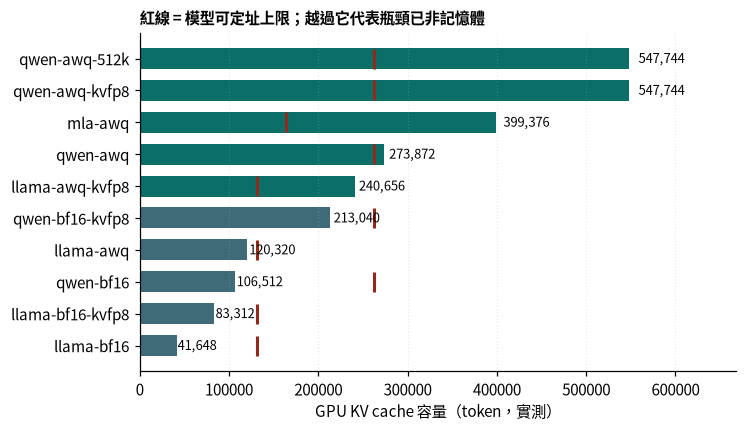

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
fig_capacity(D, ax=ax); plt.show()

---
## 5. 真實流量的重用結構

Mooncake（FAST'25）隨論文釋出的生產 trace。其 `hash_ids` 欄位就是 block 層級的
前綴共用資訊，與模擬器的輸入同構，可直接餵入。

**⚠️ 但這兩份 trace 都不是長上下文**——中位數 6,906 token，零筆達到 128K。
論文的目標情境（128K–512K）在公開資料中沒有對應的 trace。

In [9]:
df_tr = pd.DataFrame(D['traces'])
display(df_tr)
print('\n合成 Zipf α=0.9 的重用率是 85.1%，比真實流量的 36.6–55.3% 高很多。')
print('「必然重算」是誰都躲不掉的下限（compulsory miss）——Oracle 也一樣要付。')

,trace,requests,accesses,unique_blocks,reuse_pct,compulsory_pct,median_input,p99_input,over_128k
0,conversation,12031,288500,182790,36.6,63.4,6909,85401,0
1,toolagent,23608,409616,183300,55.3,44.7,6346,61671,0



合成 Zipf α=0.9 的重用率是 85.1%，比真實流量的 36.6–55.3% 高很多。
「必然重算」是誰都躲不掉的下限（compulsory miss）——Oracle 也一樣要付。


---
## 6. Oracle：headroom 有**兩個**自變數

計畫書原本假設只有「壓力」（工作集/容量）。實測顯示**重用率**同等重要。

判定門檻（實驗前就訂好，不因結果調整）：**>15% GO、5–15% 問人、<5% 停止**。

In [10]:
df_o = pd.DataFrame([{'情境': s['scenario'], '最佳 baseline': s['best_baseline'],
                     'headroom %': s['headroom_pct'], '判定': s['verdict']}
                    for s in D['oracle']])
display(df_o)
print('\n★ 最關鍵的一列：同一份流量只換權重精度')
print('  toolagent @ BF16 預算（壓力 60.9×）→ 14.1%')
print('  toolagent @ AWQ  預算（壓力 10.7×）→  4.6%')
print('  AWQ 是論文自己的主力設定。**配置越好，論文貢獻的空間越小。**')

,情境,最佳 baseline,headroom %,判定
0,pressure:1x,full_gpu,0.0,NO_GO
1,pressure:2x,cpu_arc,9.7,MARGINAL_ASK_HUMAN
2,pressure:5x,cpu_arc,20.8,GO
3,pressure:10x,cpu_arc,18.6,GO
4,pressure:20x,cpu_arc,17.4,GO
5,pressure:40x,cpu_arc,16.2,GO
6,trace:conv@48K,cpu_arc,16.4,GO
7,trace:tool@48K,cpu_lru,14.1,MARGINAL_ASK_HUMAN
8,trace:conv@274K,cpu_lru,7.3,MARGINAL_ASK_HUMAN
9,trace:tool@274K,cpu_lru,4.6,NO_GO



★ 最關鍵的一列：同一份流量只換權重精度
  toolagent @ BF16 預算（壓力 60.9×）→ 14.1%
  toolagent @ AWQ  預算（壓力 10.7×）→  4.6%
  AWQ 是論文自己的主力設定。**配置越好，論文貢獻的空間越小。**


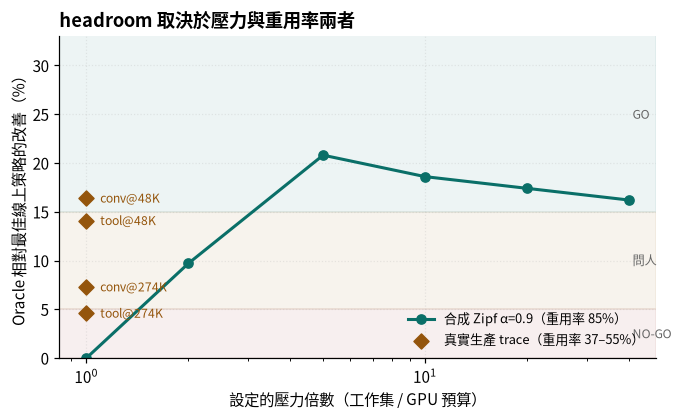

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.8))
fig_pressure(D, ax=ax); plt.show()

### 用命中次數看，而不是只看時間

命中次數是**機制**，硬體無關；時間是**結果**，依賴成本模型。

**這個視角抓到過一個 bug**：壓力 0.5× 時五個策略的命中數完全相同、時間卻差 9.7%。
命中相同時間不可能差——查出 Oracle 一直用位置 0 的價格重算，baseline 付全價。
修正後先前所有數字下修 8–9 個百分點。**用時間看永遠抓不到這個 bug。**

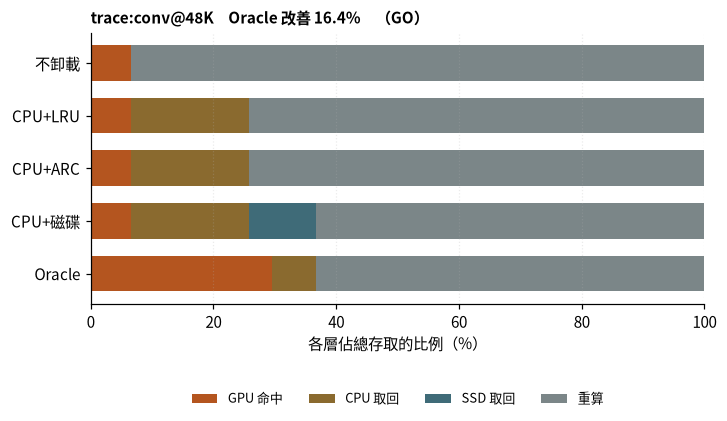

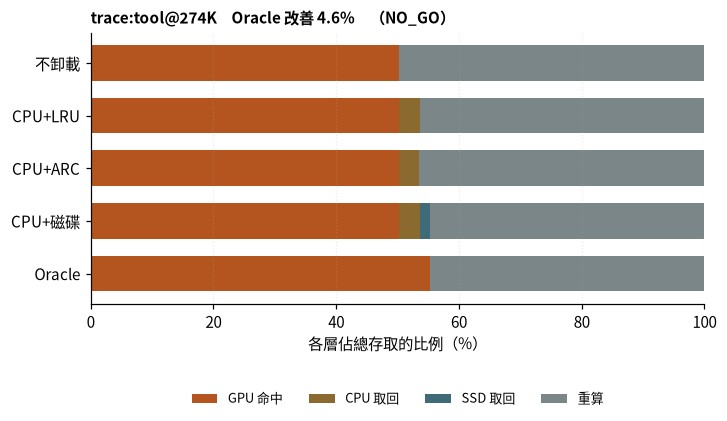

In [12]:
for sc in ('trace:conv@48K', 'trace:tool@274K'):
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    fig_policy_mix(D, sc, ax=ax); plt.show()

In [13]:
s = next(x for x in D['oracle'] if x['scenario'] == 'trace:conv@48K')
rows = []
for p, v in s['policies'].items():
    tot = sum(v[k] for k in ('gpu', 'cpu', 'ssd', 'recompute'))
    rows.append({'策略': p, 'GPU 命中': v['gpu'], 'CPU': v['cpu'], 'SSD': v['ssd'],
                 '重算': v['recompute'], 'GPU 命中率': f"{100*v['gpu']/tot:.1f}%",
                 '總時間 (s)': round(v['ms']/1000, 1)})
display(pd.DataFrame(rows))
print('\n★ Oracle 的重算次數等於不重複 block 數 → 它已打到 compulsory miss 的理論下限。')
print('  它贏的地方只有一個：「該把誰留在 GPU」。')

,策略,GPU 命中,CPU,SSD,重算,GPU 命中率,總時間 (s)
0,full_gpu,18832,0,0,269668,6.5%,1110.7
1,cpu_lru,18832,55355,0,214313,6.5%,916.0
2,cpu_arc,18905,55354,0,214241,6.6%,915.7
3,tier_fs,18832,55355,31523,182790,6.5%,960.5
4,oracle,85025,20685,0,182790,29.5%,765.6



★ Oracle 的重算次數等於不重複 block 數 → 它已打到 compulsory miss 的理論下限。
  它贏的地方只有一個：「該把誰留在 GPU」。


---
## 7. 這些數字**還不能**拿來做最終判定

| # | 已知缺陷 | 方向 | 狀態 |
|---|---|---|---|
| 1 | **精度階完全沒模擬**——Oracle 只有 {GPU, CPU, SSD, DROP} 四階，論文是六階 | Oracle **被低估** | 待修 |
| 2 | **前綴語意**：miss 記成重算一個 block，但 vLLM 是「中間缺一塊、其後全部重算」 | Oracle **被低估** | 待修 |
| 3 | **沒有預取**：取回成本在存取當下才收，等於假設永遠來不及預取 | Oracle **被低估** | 待修 |
| 4 | **模型混用**：成本常數是 Llama-BF16 的，容量預算是 Qwen-AWQ 的 | 不明 | 待修 |
| 5 | 模擬器驗證只過方向不過量級（差 1.5×） | — | 只引用趨勢 |

**1、2、3 全部往「低估」偏，所以目前的 headroom 是下界。**

### 還沒量的

- **品質 ε 的取捨曲線**：`m5_quality.py --mode mixed` 進行中（掃量化比例 f）
- **平台 B（MI300X）**：論文的 κ 跨硬體主張需要第二個平台
- **多租戶／機會成本**：24 GB 放不下兩個 128K session，此情境無法在平台 A 驗證

In [14]:
print('把所有實測數字匯出成單一 JSON，供論文的表格引用：')
import json
export = {'cost_model': {k: v for k, v in D['cost'].items() if not k.startswith('_')},
          'idle_cost_kib_per_token': D['idle'],
          'capacity': D['capacity'],
          'recompute_curve': D['recompute'],
          'recompute_fit': fit_recompute_linear(D['recompute']),
          'ssd_drop_crossover_tokens': ssd_drop_crossover(D['cost']),
          'trace_stats': D['traces'],
          'oracle': [{k: v for k, v in s.items() if k != 'policies'} for s in D['oracle']]}
with open('measured_summary.json', 'w') as f:
    json.dump(export, f, indent=2, ensure_ascii=False)
print('wrote notebooks/measured_summary.json')

把所有實測數字匯出成單一 JSON，供論文的表格引用：
wrote notebooks/measured_summary.json


---

## 2026-08-31 的修正與新資料

這一天在同一支模擬器裡找到 **六個錯誤**，所有 trace 驅動的舊數字都作廢重跑。
完整清單見 `results/RUNLOG.md`；重點是：**沒有一個是靠讀程式碼看出來的**，
全部是「同一個量兩條路徑算出來對不上」或「這在物理／邏輯上不可能」抓到的。

下面幾格用的是修正後的資料。


In [ ]:
# 磁碟頻寬實測 —— QLC 的「寫入懸崖」
# 短測（1 GiB）整個落在 SLC 快取裡，會樂觀 2.7 倍。
# KV 階是持續寫入，所以只有長測（16 GiB）的數字可以用。
df_bw = pd.DataFrame(D['disk_bw'])
df_bw['write_mibps'] = df_bw['write_mibps'].astype(float)
df_bw['read_mibps'] = df_bw['read_mibps'].astype(float)
print(df_bw.groupby(['path', 'test'])[['write_mibps', 'read_mibps']]
      .median().round(0).to_string())
print()
sata = df_bw[(df_bw.path.str.contains('ssd7')) & (df_bw.test == 'sustained')]
nvme = df_bw[df_bw.path.str.contains('home')]
print(f"SATA QLC 持續寫入 {sata.write_mibps.median():,.0f} MiB/s"
      f"　vs　NVMe {nvme.write_mibps.median():,.0f} MiB/s"
      f"　→ **{nvme.write_mibps.median() / sata.write_mibps.median():.1f}×**")
print("這就是 κ 隨硬體變動的第一個實證，而且兩顆碟在同一台機器上。")

### 為什麼「寫入」會改變結論

模擬器的成本模型只向「把 block 讀回來」收費，**寫下去是免費的**。
真實硬體不是。下面這張圖把兩件事疊在一起看：

* **線**：Oracle 相對最佳 baseline 的 headroom（延遲軸）
* **柱**：各策略需要的持續寫入頻寬（可行性軸），紅線是實測的裝置能力

延遲上只差幾個百分點，可行性上卻是「能跑 vs 不能跑」。


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
fig_ssd_feasibility(D, axes[0])
fig_write_feasibility(D, axes[1])
plt.tight_layout(); plt.show()

### 長上下文到底有沒有比較需要這套？

先前打算用「把 block 粒度放大」合成 128K/512K，但那要假設
「重用結構與請求長度無關」——沒有資料可以驗證的假設。

其實不必假設：真實 trace 裡**有**長請求，只是佔比小
（toolagent ≥64K 有 211 筆、最長 126,195 token）。
所以直接把每個請求的成本按長度分箱，看節省集中在哪一段。**零假設。**


In [ ]:
df_len = pd.DataFrame(D['by_length'])
for t in df_len['trace'].unique():
    sub = df_len[df_len.trace == t]
    print(f"\n{t}（最佳 baseline = {sub.best_baseline.iloc[0]}）")
    print(sub[['bin', 'requests', 'share_of_total_time_pct',
               'saving_pct_within_bin', 'share_of_total_saving_pct']]
          .to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4))
fig_saving_by_length(D, ax); plt.tight_layout(); plt.show()

**兩個讀法**（以 toolagent 為例）：

1. 節省率隨長度上升然後**在 ~16K 飽和**（8.27% → 13.49% → 12.87%）。
   「越長越有價值」成立，但飽和點遠低於 128K——這修正了論文原本的直覺。
2. **0.9% 的長請求（≥64K，212 筆）吃掉 25.3% 的總時間、貢獻 26.2% 的節省。**
   這是真實資料能給的最強長上下文論據：極少數長請求主導成本與機會。


In [ ]:
# 模擬器的系統語意假設各自把 headroom 推動多少
df_sem = pd.DataFrame(D['semantics'])
piv = (df_sem[df_sem.policy == 'oracle']
       .pivot_table(index='workload', columns='semantics',
                    values='oracle_headroom_pct', aggfunc='first'))
print(piv.round(2).to_string())
print()
print('lookup=prefix vs per-block：真實流量的重用本身就是前綴結構的，')
print('  第一個未命中剛好落在共用前綴的結尾，其後 87-100% 是第一次出現的 block。')
print('  所以 per-block 這個簡化對這類工作負載無害 —— 這是模擬器的有效性證據。')
print('prefetch：只能隱藏傳輸，而 Oracle 的傳輸量本來就少，所以 baseline 受益較多。')